In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

url_pokemon = "https://raw.githubusercontent.com/KeithGalli/pandas/master/pokemon_data.csv"

df_pokemon = pd.read_csv(url_pokemon)

print("Tamaño de la base de datos:")
print(df_pokemon.shape)

print("\n--- Los primeros 5 Pokémon ---")
print(df_pokemon.head())

Tamaño de la base de datos:
(800, 12)

--- Los primeros 5 Pokémon ---
   #                   Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation  Legendary
0  1              Bulbasaur  Grass  Poison  45      49       49       65       65     45           1      False
1  2                Ivysaur  Grass  Poison  60      62       63       80       80     60           1      False
2  3               Venusaur  Grass  Poison  80      82       83      100      100     80           1      False
3  3  VenusaurMega Venusaur  Grass  Poison  80     100      123      122      120     80           1      False
4  4             Charmander   Fire     NaN  39      52       43       60       50     65           1      False


In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

url_pokemon = "https://raw.githubusercontent.com/KeithGalli/pandas/master/pokemon_data.csv"
df_pokemon = pd.read_csv(url_pokemon)

print("--- Resumen Matemático Rápido ---")
print(df_pokemon.describe())

top_ataque = df_pokemon.sort_values(by="Attack", ascending=False)
top_defensa = df_pokemon.sort_values(by="Defense", ascending=False)

print("\n--- ⚔️ Top 5 Pokémon con más Ataque ---")
print(top_ataque[["Name","Type 1", "Attack"]].head())

print("\n--- Top 5 Pokémon con más Defensa ---")
print(top_defensa[["Name", "Type 1", "Defense"]].head())

--- Resumen Matemático Rápido ---
                #          HP      Attack     Defense     Sp. Atk     Sp. Def       Speed  Generation
count  800.000000  800.000000  800.000000  800.000000  800.000000  800.000000  800.000000   800.00000
mean   362.813750   69.258750   79.001250   73.842500   72.820000   71.902500   68.277500     3.32375
std    208.343798   25.534669   32.457366   31.183501   32.722294   27.828916   29.060474     1.66129
min      1.000000    1.000000    5.000000    5.000000   10.000000   20.000000    5.000000     1.00000
25%    184.750000   50.000000   55.000000   50.000000   49.750000   50.000000   45.000000     2.00000
50%    364.500000   65.000000   75.000000   70.000000   65.000000   70.000000   65.000000     3.00000
75%    539.250000   80.000000  100.000000   90.000000   95.000000   90.000000   90.000000     5.00000
max    721.000000  255.000000  190.000000  230.000000  194.000000  230.000000  180.000000     6.00000

--- ⚔️ Top 5 Pokémon con más Ataque ---
       

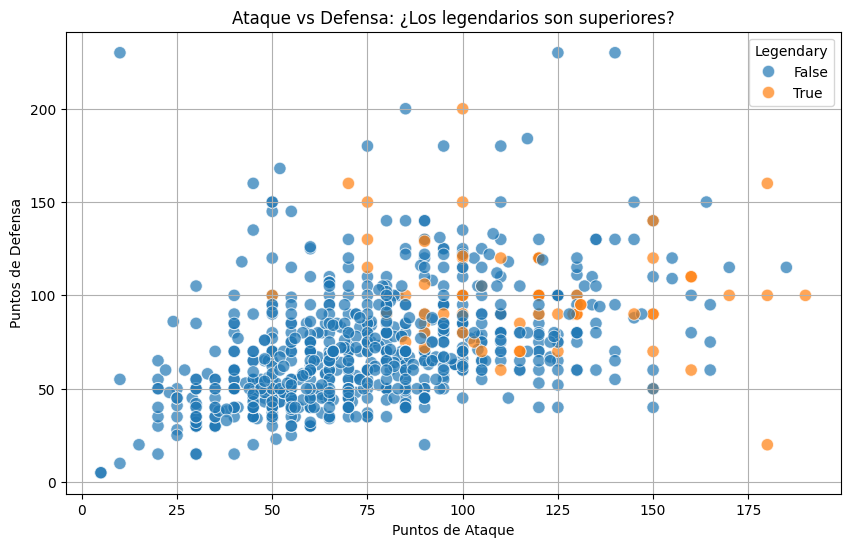

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

url_pokemon = "https://raw.githubusercontent.com/KeithGalli/pandas/master/pokemon_data.csv"
df_pokemon = pd.read_csv(url_pokemon)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_pokemon, x="Attack", y="Defense", hue="Legendary", s=80, alpha=0.7)

plt.title("Ataque vs Defensa: ¿Los legendarios son superiores?")
plt.xlabel("Puntos de Ataque")
plt.ylabel("Puntos de Defensa")
plt.grid(True)

plt.show()

In [4]:
import pandas as pd
import sqlite3

url_pokemon = "https://raw.githubusercontent.com/KeithGalli/pandas/master/pokemon_data.csv"
df_pokemon = pd.read_csv(url_pokemon)

conexion = sqlite3.connect(":memory:")

df_pokemon.to_sql("tabla_pokemon", conexion, index=False)

mi_primera_query = """
    SELECT Name, "Type 1", Speed
    FROM tabla_pokemon
    WHERE Speed > 140
"""

resultado_sql = pd.read_sql(mi_primera_query, conexion)

print(" Pokémon súper rápidos (Velocidad > 140) usando SQL")
print(resultado_sql)

 Pokémon súper rápidos (Velocidad > 140) usando SQL
                        Name   Type 1  Speed
0      BeedrillMega Beedrill      Bug    145
1      AlakazamMega Alakazam  Psychic    150
2  AerodactylMega Aerodactyl     Rock    150
3      SceptileMega Sceptile    Grass    145
4                    Ninjask      Bug    160
5         DeoxysNormal Forme  Psychic    150
6         DeoxysAttack Forme  Psychic    150
7          DeoxysSpeed Forme  Psychic    180
8                   Accelgor      Bug    145


In [5]:
import pandas as pd
import sqlite3

url_pokemon = "https://raw.githubusercontent.com/KeithGalli/pandas/master/pokemon_data.csv"
df_pokemon = pd.read_csv(url_pokemon)

conexion = sqlite3.connect(":memory:")

df_pokemon.to_sql("tabla_pokemon", conexion, index=False)

mi_segunda_query = """
    SELECT Name, "Type 1", HP
    FROM tabla_pokemon
    WHERE HP > 150
"""

resultado_sql = pd.read_sql(mi_segunda_query, conexion)

print(" Pokémon súper rápidos (Velocidad > 140) usando SQL")
print(resultado_sql)

 Pokémon súper rápidos (Velocidad > 140) usando SQL
        Name   Type 1   HP
0    Chansey   Normal  250
1    Snorlax   Normal  160
2  Wobbuffet  Psychic  190
3    Blissey   Normal  255
4    Wailord    Water  170
5  Alomomola    Water  165


In [6]:
query_agrupada = """
    SELECT "Type 1", AVG(HP) AS Promedio_HP
    FROM tabla_pokemon
    GROUP BY "Type 1"
    ORDER BY Promedio_HP DESC
"""

resultado_agrupado = pd.read_sql(query_agrupada, conexion)

print("\n--- Promedio de HP por Tipo ---")
print(resultado_agrupado)


--- Promedio de HP por Tipo ---
      Type 1  Promedio_HP
0     Dragon    83.312500
1     Normal    77.275510
2      Fairy    74.117647
3     Ground    73.781250
4      Water    72.062500
5        Ice    72.000000
6     Flying    70.750000
7    Psychic    70.631579
8       Fire    69.903846
9   Fighting    69.851852
10     Grass    67.271429
11    Poison    67.250000
12      Dark    66.806452
13      Rock    65.363636
14     Steel    65.222222
15     Ghost    64.437500
16  Electric    59.795455
17       Bug    56.884058
